In [1]:
#we may need some code in the ../python directory and/or matplotlib styles
import sys
sys.path.append('../python/')

#matplotlib for plotting
import matplotlib as mpl
from matplotlib import pyplot as plt
plt.style.use('../mplstyles/stylelib/standard.mplstyle')

#other computational libraries
import numpy as np
import pandas as pds
import math
import time

In [2]:
#set up the parameters for the cylindrical detector
R = 5.5/2
h = 5.5
a = 1.3

In [3]:
from scipy import integrate
#def cos_int(x):
#  f = lambda u: (a+1)*np.power(u,a)
#  return integrate.quad(f,0,x)[0]

def cos_int(x):
    f = lambda u: (a + 1) * np.power(u, a)

    if np.isscalar(x):
        return integrate.quad(f, 0, x)[0]
    else:
        return np.array([integrate.quad(f, 0, xi)[0] for xi in x])

print(cos_int(0.9999999))

from scipy import optimize
#def inv_cos_int(y):
#  g = lambda v: cos_int(v)-y
#  return optimize.root(g,0.5).x[0]

def inv_cos_int(y):
    
    def solve_one(yi):
        g = lambda v: cos_int(v) - yi
        return optimize.root(g, 0.5).x[0]

    if np.isscalar(y):
        return solve_one(y)
    else:
        y = np.asarray(y)
        return np.array([solve_one(yi) for yi in y])

print(inv_cos_int([0.5,0.6]))
print(cos_int(0.8409))

0.999999770000015
[0.73980522 0.8008368 ]
0.6712928333118727


In [4]:
#the monte carlo way
start = time.time()
L = 10*R
N = int(1e8)
X = np.random.uniform(-L,L,N)
Y = np.random.uniform(-L,L,N)
R0 = np.sqrt(X**2,Y**2)

end = time.time()

print('Evaluation Time (Radial): {:1.5f} sec. for {:7d} points'.format(end-start,N))

#generate angles

phi = np.random.uniform(-np.pi,np.pi,N)
start = time.time()

#try accept/reject memthod from GPT version instead
costhet = np.random.rand(N)
accept = np.random.rand(N) < np.power(costhet,a)
#inv_costhet = np.random.uniform(0,1,N)
#costhet = inv_cos_int(inv_costhet)
end = time.time()

#recast all vectors
X = X[accept]
Y = Y[accept]
R0 = R0[accept]
costhet = costhet[accept]
phi = phi[accept]

print('Evaluation Time (Angular): {:1.5f} sec. for {:7d} points'.format(end-start,np.sum(accept)))


#slice things up

cInside = (R0<=R)
cInWall = cInside&(costhet<(R/np.sqrt(R**2+h**2)))
cInTop = cInside&(costhet>=(R/np.sqrt(R**2+h**2)))
#print(np.shape(R0[cInWall]),np.shape(R0[cInTop]))

lall = []


r=R0
#print(R/r)
#print(np.max(R/r),np.min(R/r))
r_out = r[~cInside]
phi_out = phi[~cInside]
costhet_out = costhet[~cInside]

cPhi = (-np.arcsin(R/r_out)<phi_out)&(phi_out<np.arcsin(R/r_out))

r_out = r_out[cPhi]
phi_out = phi_out[cPhi]
costhet_out = costhet_out[cPhi]

t_out = 2*np.sqrt(R**2 - r_out**2*np.sin(phi_out)**2)
d_out = r_out*np.cos(phi_out) - np.sqrt(R**2 - r_out**2*np.sin(phi_out)**2)

maxcos = h/np.sqrt((d_out+t_out)**2+h**2)
mincos = h/np.sqrt(d_out**2+h**2)


###split side entry from top entry. 
cCos_side = (costhet_out>0)&(costhet_out<=maxcos)
cCos_top = (costhet_out>maxcos)&(costhet_out<=mincos)

#side
r_side = r_out[cCos_side]
phi_side = phi_out[cCos_side]
costhet_side = costhet_out[cCos_side]
t_side = t_out[cCos_side]
d_side = d_out[cCos_side]

lcomp_side = t_side/np.sqrt(1-costhet_side**2)

#top
r_top = r_out[cCos_top]
phi_top = phi_out[cCos_top]
costhet_top = costhet_out[cCos_top]
t_top = t_out[cCos_top]
d_top = d_out[cCos_top]

cot_top = costhet_top/np.sqrt(1-costhet_top**2)
lcomp_top = (h-d_top*cot_top)/costhet_top

#lall = np.append(lcomp_side,lcomp_top)

#print(R0)
print(np.shape(R0),np.shape(lall))



Evaluation Time (Radial): 1.05057 sec. for 100000000 points
Evaluation Time (Angular): 2.44496 sec. for 43473145 points
(43473145,) (0,)


In [10]:
#now do inside
r=R0
#print(R/r)
#print(np.max(R/r),np.min(R/r))
r_in = r[cInside]
phi_in = phi[cInside]
costhet_in = costhet[cInside]

t_in = r_in*np.cos(phi_in) + np.sqrt(R**2 - r_in**2*np.sin(phi_in)**2)

cosbound_in = h/np.sqrt(t_in**2+h**2)


###split side entry from top entry. 
cCos_in_side = (costhet_in>0)&(costhet_in<=cosbound_in)
cCos_in_top = (costhet_in>cosbound_in)

#side
r_in_side = r_in[cCos_in_side]
costhet_in_side = costhet_in[cCos_in_side]
t_in_side = t_in[cCos_in_side]


lcomp_in_side = t_in_side/np.sqrt(1-costhet_in_side**2)

#top
r_in_top = r_in[cCos_in_top]
phi_in_top = phi_in[cCos_in_top]
costhet_in_top = costhet_in[cCos_in_top]
t_in_top = t_in[cCos_in_top]

lcomp_in_top = h/costhet_in_top

300.86738362655007 0.18483714072712804
7.765602940139526 5.742699827917265e-07


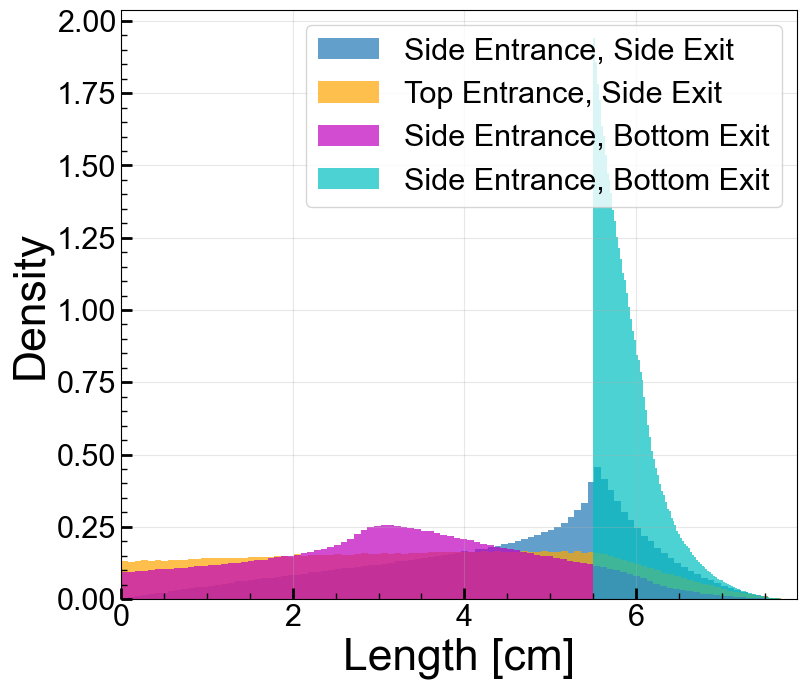

In [11]:
print(np.max(cot_top),np.min(cot_top))
print(np.max(lcomp_top),np.min(lcomp_top))

# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 7))


xmax = np.sqrt((2*R)**2+h**2)+0.1
xplot = np.linspace(0,xmax, 10000)

ax1.hist(lcomp_side, bins=100, density=True, alpha=0.7, label='Side Entrance, Side Exit',align='mid')
ax1.hist(lcomp_top, bins=100, density=True, alpha=0.7, label='Top Entrance, Side Exit',align='mid', color='orange')
ax1.hist(lcomp_in_side, bins=100, density=True, alpha=0.7, label='Side Entrance, Bottom Exit',align='mid', color='m')
ax1.hist(lcomp_in_top, bins=100, density=True, alpha=0.7, label='Top Entrance, Bottom Exit',align='mid', color='c')


ax1.set_xlim(0.0, xmax) 
ax1.set_ylabel('Density')
ax1.set_xlabel('Length [cm]')
#ax1.set_title('Histogram of Chi-Square per DOF')
ax1.legend()
ax1.grid(True, alpha=0.3)


# Adjust layout and save
plt.tight_layout()
plt.show()

300.86738362655007 0.18483714072712804
7.765602940139526 5.742699827917265e-07


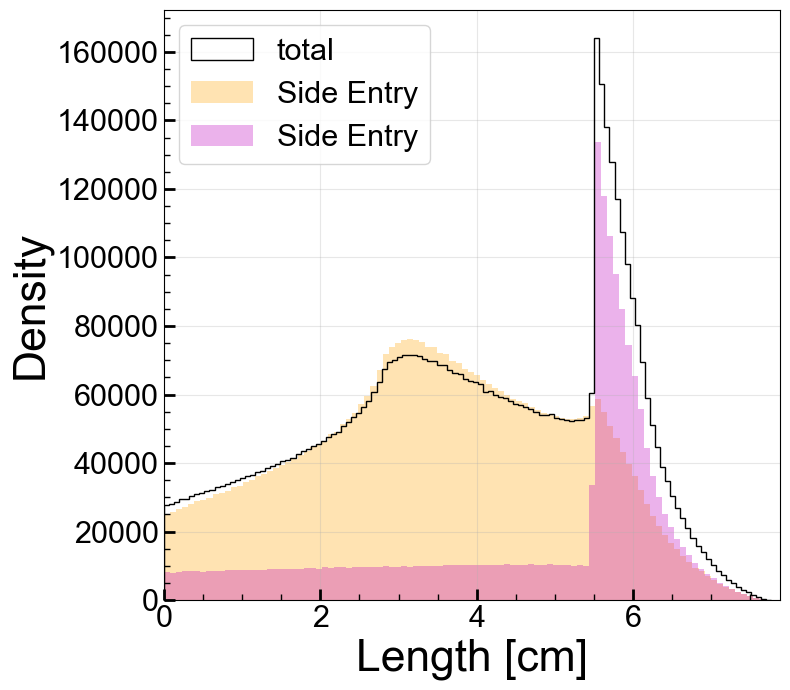

In [18]:
print(np.max(cot_top),np.min(cot_top))
print(np.max(lcomp_top),np.min(lcomp_top))

# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 7))


xmax = np.sqrt((2*R)**2+h**2)+0.1
xplot = np.linspace(0,xmax, 10000)

lengths = np.append(lcomp_side,lcomp_in_side)
lengths = np.append(lengths,lcomp_top)
lengths = np.append(lengths,lcomp_in_top)

plt.hist(lengths, bins=120, density=False,alpha=1.0,label='total',histtype='step',color='k')
ax1.hist(np.append(lcomp_side,lcomp_in_side), bins=100, density=False, alpha=0.3, label='Side Entry',align='mid',color='orange')
ax1.hist(np.append(lcomp_top,lcomp_in_top), bins=100, density=False, alpha=0.3, label='Side Entry',align='mid',color='m')



ax1.set_xlim(0.0, xmax) 
ax1.set_ylabel('Density')
ax1.set_xlabel('Length [cm]')
#ax1.set_title('Histogram of Chi-Square per DOF')
ax1.legend()
ax1.grid(True, alpha=0.3)


# Adjust layout and save
plt.tight_layout()
plt.show()